In [ ]:
import numpy as np
import pandas as pd
import librosa
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


# ── 1. AUDIO FEATURES ─────────────────────────────

def get_audio_features(path):
    try:
        y, sr = librosa.load(path, sr=16000, duration=5)

        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=10)

        return np.hstack([
            mfcc.mean(axis=1),
            mfcc.std(axis=1),
            [np.mean(y), np.std(y)]
        ])
    except:
        return np.zeros(22)


# ── 2. CREATE FEATURES ─────────────────────────────

def create_features(df, vectorizer=None, train=True):

    # TEXT
    texts = df["text"].fillna("")

    if train:
        vectorizer = TfidfVectorizer(max_features=200)
        text_features = vectorizer.fit_transform(texts)
    else:
        text_features = vectorizer.transform(texts)

    text_features = text_features.toarray()

    # AUDIO
    audio_features = np.array([
        get_audio_features(p) if p else np.zeros(22)
        for p in df["audio_path"]
    ])

    # DEMOGRAPHICS
    age = df["age"].fillna(0).values.reshape(-1, 1) / 100
    gender = df["gender"].fillna(0).values.reshape(-1, 1)

    # COMBINE
    X = np.hstack([text_features, audio_features, age, gender])

    return X, vectorizer


# ── 3. TRAIN MODEL ─────────────────────────────

def train_model(df):

    train_df, test_df = train_test_split(df, test_size=0.2)

    X_train, vec = create_features(train_df, train=True)
    X_test, _ = create_features(test_df, vectorizer=vec, train=False)

    y_train = train_df["label"]
    y_test = test_df["label"]

    model = GradientBoostingClassifier()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("\nResults:\n")
    print(classification_report(y_test, y_pred))

    return model, vec


# ── 4. PREDICT ─────────────────────────────

def predict(model, vec, text, age=0, gender=0):

    df = pd.DataFrame([{
        "text": text,
        "audio_path": "",
        "age": age,
        "gender": gender
    }])

    X, _ = create_features(df, vectorizer=vec, train=False)

    prob = model.predict_proba(X)[0][1]

    return {
        "Depressed": prob > 0.5,
        "Confidence": round(prob, 2)
    }


# ── 5. LOAD YOUR DATASET ─────────────────────────────

df = pd.read_csv("/content/sample_data/Student Depression Dataset (1).csv")

print("Columns in dataset:", df.columns)

#  Rename columns (EDIT THIS based on your dataset)
df = df.rename(columns={
    "Text": "text",
    "Depression": "label"
})

#  Add missing columns
df["audio_path"] = ""
df["age"] = 25
df["gender"] = 0

#  Convert label to numeric if needed
try:
    df["label"] = df["label"].astype(int)
except:
    df["label"] = df["label"].map({
        "Yes": 1,
        "No": 0,
        "Depressed": 1,
        "Not Depressed": 0
    })
    df = pd.read_csv("/content/sample_data/Student Depression Dataset (1).csv")

# Create text column
df["text"] = (
    df["Profession"].astype(str) + " " +
    df["Sleep Duration"].astype(str) + " " +
    df["Dietary Habits"].astype(str) + " " +
    df["Work Pressure"].astype(str)
)

# Rename label
df = df.rename(columns={"Depression": "label"})

# Add required columns
df["audio_path"] = ""
df["age"] = df["Age"]
df["gender"] = df["Gender"]

# Convert gender
df["gender"] = df["gender"].map({
    "Male": 1,
    "Female": 0
})

# Ensure label is numeric
df["label"] = df["label"].astype(int)

# ── 6. TRAIN ─────────────────────────────

model, vec = train_model(df)


# ── 7. TEST PREDICTION ─────────────────────────────

result = predict(
    model, vec,
    text="I feel very tired and hopeless",
    age=21,
    gender=1
)

print("\nPrediction:", result)

Columns in dataset: Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

Results:

              precision    recall  f1-score   support

           0       0.64      0.45      0.53      2327
           1       0.67      0.82      0.74      3254

    accuracy                           0.66      5581
   macro avg       0.66      0.63      0.63      5581
weighted avg       0.66      0.66      0.65      5581


Prediction: {'Depressed': np.True_, 'Confidence': np.float64(0.92)}


In [ ]:
print(df.columns)

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'label',
       'audio_path', 'age', 'gender', 'text'],
      dtype='object')


Saving Student Depression Dataset (1).csv to Student Depression Dataset (1) (3).csv
Shape: (27901, 18)

Columns: ['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']

First 5 rows:

=== Missing Values ===
id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree               

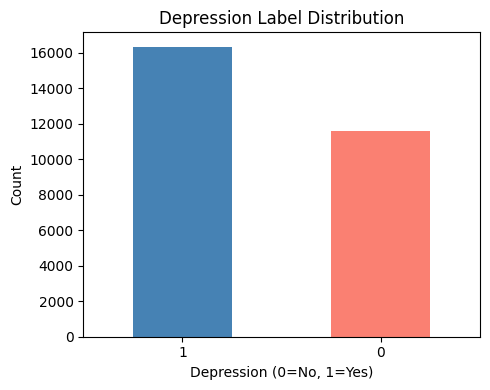


Using 8 numeric columns: ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']
Using 8 categorical columns: ['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']

Feature matrix shape: (27901, 16)
Target distribution:
Depression
1    16336
0    11565
Name: count, dtype: int64

Train size: 22320
Test  size: 5581

  Logistic Regression
  Accuracy  : 0.8395
  ROC-AUC   : 0.9172
  CV F1 Mean: 0.8645

  Classification Report:
               precision    recall  f1-score   support

No Depression       0.79      0.83      0.81      2313
   Depression       0.88      0.84      0.86      3268

     accuracy                           0.84      5581
    macro avg       0.83      0.84      0.84      5581
 weighted avg       0.84      0.84      0.84      5581


  Random Forest
  Accuracy  : 0.8352
  ROC-AUC   : 0.913

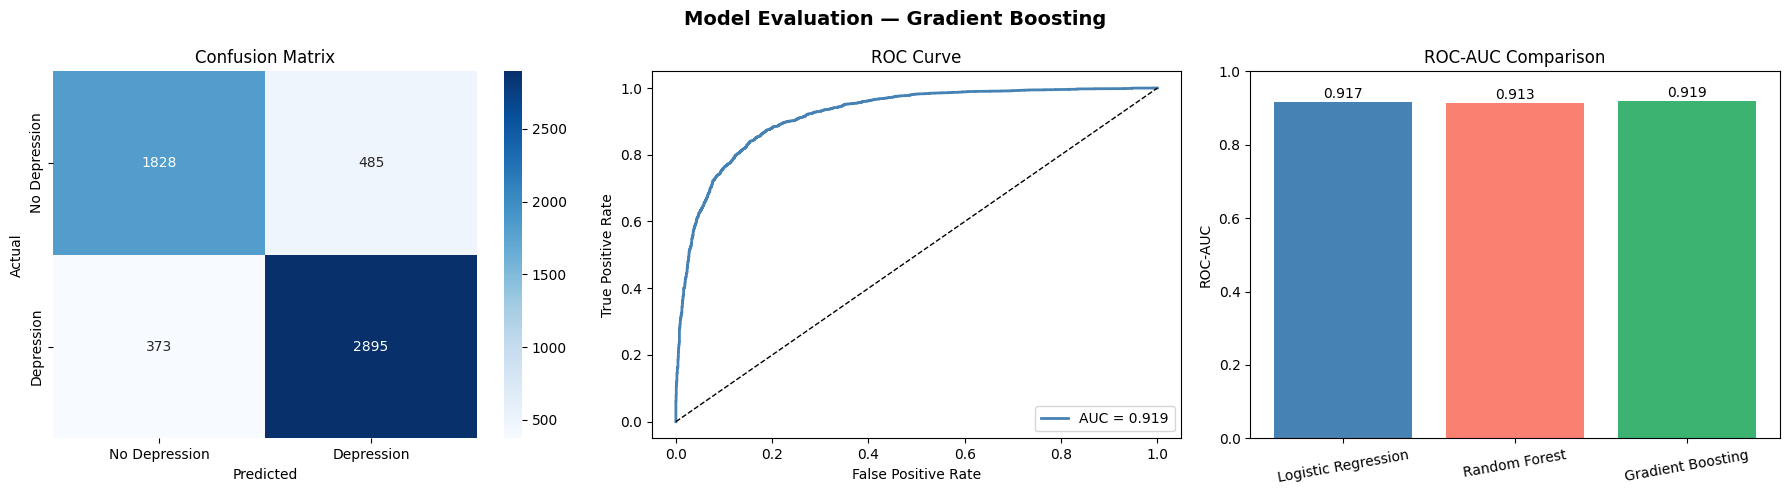

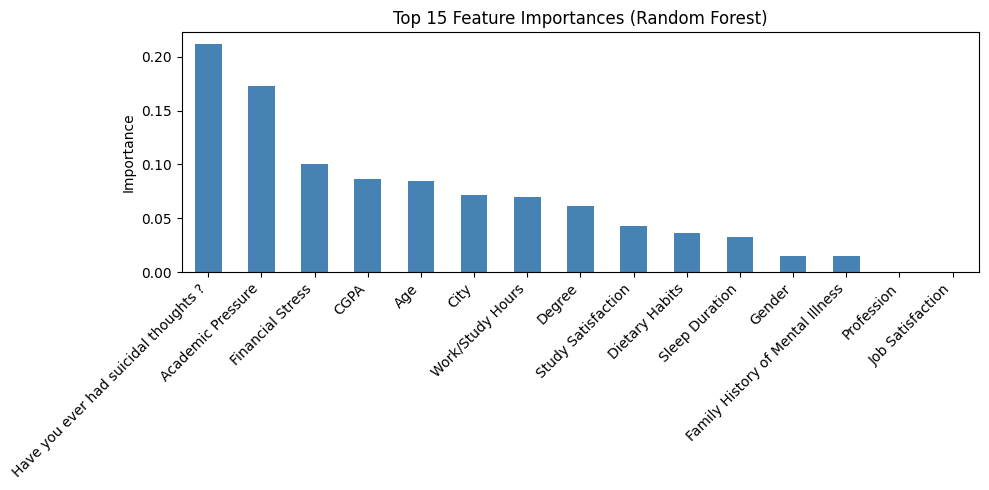


Top 10 most important features:
Have you ever had suicidal thoughts ?    0.212181
Academic Pressure                        0.172879
Financial Stress                         0.100136
CGPA                                     0.086257
Age                                      0.084201
City                                     0.071883
Work/Study Hours                         0.069594
Degree                                   0.061185
Study Satisfaction                       0.042398
Dietary Habits                           0.036094
dtype: float64

=== Sample Prediction ===
Prediction : No Depression
Probability: 33.38%


In [ ]:
# ============================================================
# Student Depression Prediction - Full ML Pipeline
# ============================================================

# ── 1. Install & Imports ─────────────────────────────────────


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)


# ── 2. Load Data ─────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('/content/Student Depression Dataset (1).csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()


# ── 3. Basic EDA ─────────────────────────────────────────────
print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Label Distribution ===")
print(df["Depression"].value_counts())
print(f"Depression rate: {df['Depression'].mean()*100:.1f}%")

# Plot label distribution
plt.figure(figsize=(5, 4))
df["Depression"].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title("Depression Label Distribution")
plt.xlabel("Depression (0=No, 1=Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ── 4. Feature Engineering ───────────────────────────────────

# Define column types — adjust based on your actual dataset columns
NUMERIC_COLS = [
    'Age', 'Academic Pressure', 'Work Pressure',
    'CGPA', 'Study Satisfaction', 'Job Satisfaction',
    'Work/Study Hours', 'Financial Stress'
]

CATEGORICAL_COLS = [
    'Gender', 'City', 'Profession', 'Sleep Duration',
    'Dietary Habits', 'Degree',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness'
]

TARGET = 'Depression'

# Filter to only columns that exist in the dataset
NUMERIC_COLS    = [c for c in NUMERIC_COLS    if c in df.columns]
CATEGORICAL_COLS = [c for c in CATEGORICAL_COLS if c in df.columns]

print(f"\nUsing {len(NUMERIC_COLS)} numeric columns: {NUMERIC_COLS}")
print(f"Using {len(CATEGORICAL_COLS)} categorical columns: {CATEGORICAL_COLS}")

# Fill missing values
df[NUMERIC_COLS] = df[NUMERIC_COLS].fillna(df[NUMERIC_COLS].median())
df[CATEGORICAL_COLS] = df[CATEGORICAL_COLS].fillna("Unknown")

# Encode categorical columns
label_encoders = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Build feature matrix
FEATURE_COLS = NUMERIC_COLS + CATEGORICAL_COLS
X = df[FEATURE_COLS]
y = df[TARGET].astype(int)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")


# ── 5. Train / Test Split ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test  size: {X_test.shape[0]}")


# ── 6. Feature Scaling ───────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)          # ← transform only, never re-fit


# ── 7. Train Multiple Models ─────────────────────────────────
models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, random_state=42
    ),
}

results = {}

for name, model in models.items():
    # Logistic Regression works better with scaled data
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred  = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
    else:
        model.fit(X_train, y_train)
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')

    acc     = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    cv_mean = cv_scores.mean()

    results[name] = {
        "model":    model,
        "y_pred":   y_pred,
        "y_proba":  y_proba,
        "accuracy": acc,
        "roc_auc":  roc_auc,
        "cv_f1":    cv_mean,
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  ROC-AUC   : {roc_auc:.4f}")
    print(f"  CV F1 Mean: {cv_mean:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["No Depression", "Depression"]))


# ── 8. Select Best Model ─────────────────────────────────────
best_name = max(results, key=lambda k: results[k]["roc_auc"])
best      = results[best_name]
print(f"\n Best Model by ROC-AUC: {best_name} ({best['roc_auc']:.4f})")


# ── 9. Visualisations ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Model Evaluation — {best_name}", fontsize=14, fontweight='bold')

# (A) Confusion Matrix
cm = confusion_matrix(y_test, best["y_pred"])
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=["No Depression", "Depression"],
    yticklabels=["No Depression", "Depression"]
)
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# (B) ROC Curve
fpr, tpr, _ = roc_curve(y_test, best["y_proba"])
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f"AUC = {best['roc_auc']:.3f}")
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

# (C) Model Comparison
model_names = list(results.keys())
aucs = [results[m]["roc_auc"] for m in model_names]
bars = axes[2].bar(model_names, aucs, color=['steelblue', 'salmon', 'mediumseagreen'])
axes[2].set_ylim(0, 1)
axes[2].set_title("ROC-AUC Comparison")
axes[2].set_ylabel("ROC-AUC")
axes[2].set_xticklabels(model_names, rotation=10)
for bar, val in zip(bars, aucs):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f"{val:.3f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()


# ── 10. Feature Importance (Random Forest) ───────────────────
rf_model = results["Random Forest"]["model"]
importances = pd.Series(
    rf_model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.head(15).plot(kind='bar', color='steelblue')
plt.title("Top 15 Feature Importances (Random Forest)")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(importances.head(10))


# ── 11. Predict on New Sample ────────────────────────────────
print("\n=== Sample Prediction ===")


sample = pd.DataFrame([{col: 0 for col in FEATURE_COLS}])


if best_name == "Logistic Regression":
    sample_scaled = scaler.transform(sample)
    pred  = best["model"].predict(sample_scaled)[0]
    proba = best["model"].predict_proba(sample_scaled)[0][1]
else:
    pred  = best["model"].predict(sample)[0]
    proba = best["model"].predict_proba(sample)[0][1]

print(f"Prediction : {'Depression' if pred == 1 else 'No Depression'}")
print(f"Probability: {proba:.2%}")